In [174]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv


In [175]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# House Price Prediction — End-to-End ML Project

**Dataset:** [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price)  
**Goal:** Build a complete regression pipeline to predict house prices in India, from raw data to an exported model ready for a FastAPI backend.

---

## 1. Load & Inspect

We start by loading the raw dataset (187,531 rows, 21 columns) and inspecting its structure, data types, and missing values.

In [176]:
df = pd.read_csv("/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv")

print("Shape:", df.shape)
df.head()




Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [177]:
data = df.copy()

---

## 2. Data Cleaning & Feature Engineering

The dataset is intentionally messy. In this section we handle:

- **Price parsing**: converting text like `"42 Lac"` / `"1.2 Cr"` into numeric rupees.
- **Area parsing**: extracting numbers from `"500 sqft"` / `"140 sqm"` and normalizing to `sqft`.
- **Floor parsing**: extracting the floor number from `"3 out of 10"` and handling `"Ground"` / `"Basement"`.
- **Numeric conversion**: `Bathroom`, `Balcony`, `Car Parking`.
- **High-cardinality handling**: keeping only the top-50 locations, grouping the rest into `"Other"`.
- **Outlier removal**: dropping listings with absurd price-per-sqft (below 1st or above 99th percentile).

In [178]:
def parse_amount(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    try:
        if "lac" in x:
            value = float(x.replace("lac", "").strip())
            return value * 100_000

        if "cr" in x:
            value = float(x.replace("cr", "").strip())
            return value * 10_000_000

        return float(x.replace(",", ""))

    except (ValueError, TypeError):
        return np.nan

In [179]:
data["price_clean"] = data["Amount(in rupees)"].apply(parse_amount)

data[["Amount(in rupees)", "price_clean"]].head(10)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [180]:
data = data.dropna(subset=["price_clean"]).copy()

print("Shape after removing missing prices:", data.shape)

Shape after removing missing prices: (177847, 22)


In [181]:
def parse_area(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    try:
        if "sqft" in x:
            return float(re.findall(r"[\d.]+", x)[0])

        if "sqm" in x:
            value = float(re.findall(r"[\d.]+", x)[0])
            return value * 10.764

        return np.nan

    except (ValueError, IndexError):
        return np.nan

In [182]:
data["carpet_area_sqft"] = data["Carpet Area"].apply(parse_area)
data[["Carpet Area", "carpet_area_sqft"]].head(10)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [183]:
def parse_floor(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if "ground" in x:
        return 0

    match = re.search(r"\d+", x)

    if match:
        return int(match.group())

    return np.nan

In [184]:
data["floor_num"] = data["Floor"].apply(parse_floor)
data[["Floor", "floor_num"]].head(10)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [185]:
data["Bathroom"] = pd.to_numeric(
    data["Bathroom"],
    errors="coerce"
)

In [186]:
data["Balcony"] = pd.to_numeric(
    data["Balcony"],
    errors="coerce"
)

In [187]:
top_locations = data["location"].value_counts().head(50).index

data["location_grouped"] = data["location"].where(
    data["location"].isin(top_locations),
    "Other"
)

In [188]:
print(data["location_grouped"].value_counts().head(20))

location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Other             2992
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
visakhapatnam     1729
mohali            1479
zirakpur          1478
chandigarh        1402
Name: count, dtype: int64


In [189]:
numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "Bathroom",
    "Balcony"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

target = "price_clean"

In [190]:
features = numeric_features + categorical_features

print("Features:")
for feature in features:
    print("-", feature)

print("\nTarget:")
print("-", target)

Features:
- carpet_area_sqft
- floor_num
- Bathroom
- Balcony
- location_grouped
- Furnishing
- Transaction
- Ownership
- facing

Target:
- price_clean


In [191]:
data[features + [target]].isna().sum()

carpet_area_sqft    80991
floor_num            6950
Bathroom              789
Balcony             47175
location_grouped        0
Furnishing           2067
Transaction            67
Ownership           61925
facing              65736
price_clean             0
dtype: int64

---

## 3. Exploratory Data Analysis (EDA)

We visualize the cleaned data to understand price distribution, the relationship between area and price, and how categorical features influence price.

### 3.1 Price Distribution (Log Scale)

Prices are heavily right-skewed, so we plot them on a log scale for readability.

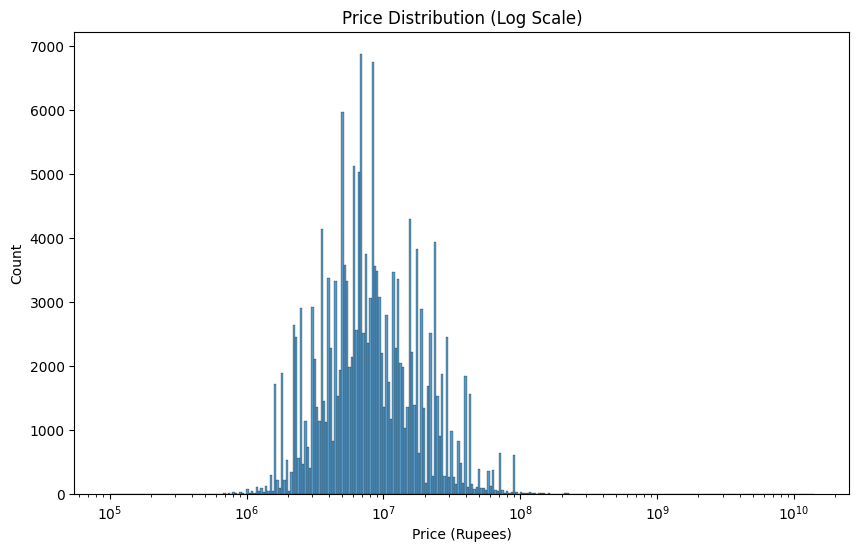

In [192]:
plt.figure(figsize=(10, 6))

sns.histplot(data["price_clean"], log_scale=True)

plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (Rupees)")
plt.ylabel("Count")

plt.show()

In [193]:
data["price_per_sqft"] = (
    data["price_clean"] / data["carpet_area_sqft"]
)

data = data[
    (data["price_clean"] > 0) &
    (data["carpet_area_sqft"] > 0) &
    (data["price_per_sqft"] > 0)
].copy()

lower = data["price_per_sqft"].quantile(0.01)
upper = data["price_per_sqft"].quantile(0.99)

print("1st percentile:", lower)
print("99th percentile:", upper)

data = data[
    data["price_per_sqft"].between(lower, upper)
].copy()

print("Shape after outlier removal:", data.shape)

1st percentile: 2692.3076923076924
99th percentile: 36000.0
Shape after outlier removal: (95263, 26)


In [194]:
features = [
    "carpet_area_sqft",
    "floor_num",
    "Bathroom",
    "Balcony",
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

target = "price_clean"

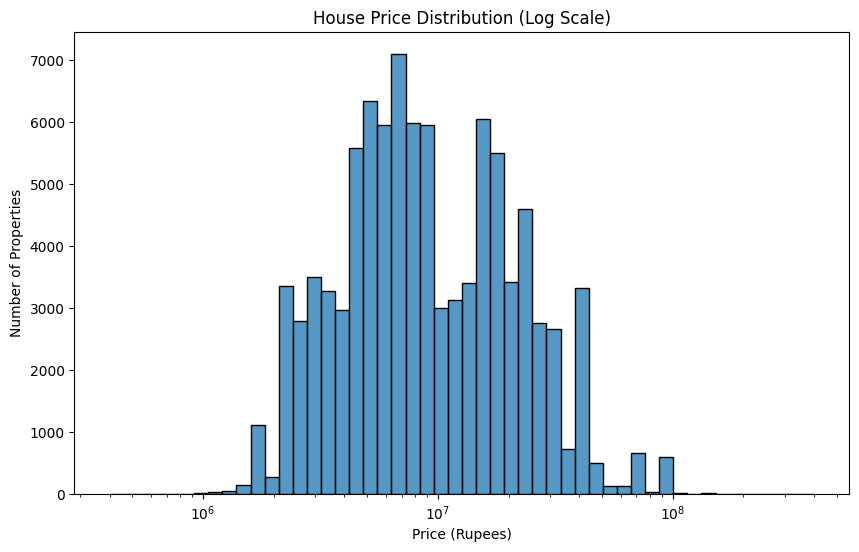

In [195]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data["price_clean"],
    bins=50,
    log_scale=True
)

plt.title("House Price Distribution (Log Scale)")
plt.xlabel("Price (Rupees)")
plt.ylabel("Number of Properties")

plt.show()

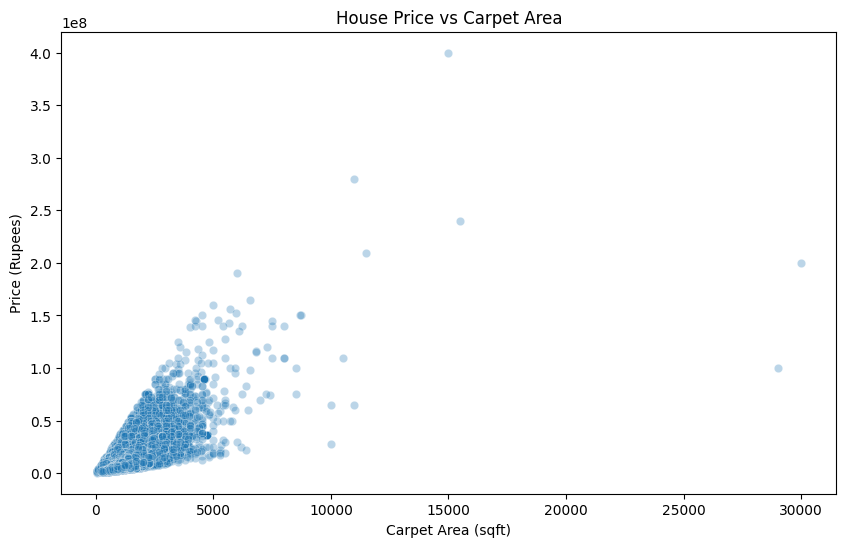

In [196]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.3
)

plt.title("House Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")

plt.show()

### 3.3 Average Price by Top 15 Locations

Location is one of the strongest predictors of price. Here we show the top 15 locations ranked by average property price.

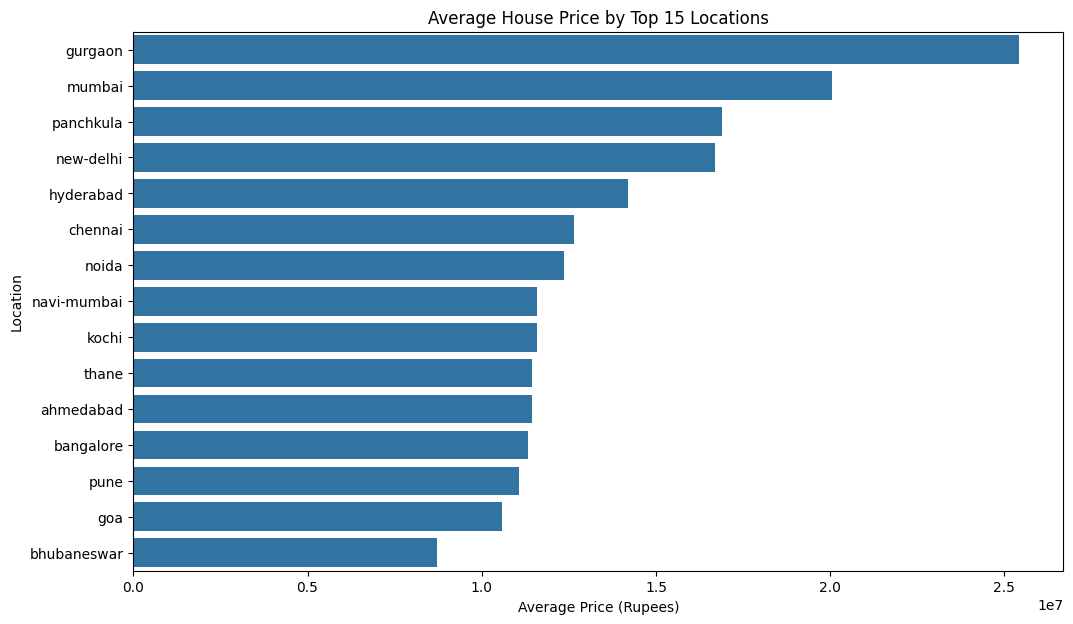

In [197]:
top_15_locations = (
    data.groupby("location_grouped")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_15_locations.values,
    y=top_15_locations.index
)

plt.title("Average House Price by Top 15 Locations")
plt.xlabel("Average Price (Rupees)")
plt.ylabel("Location")

plt.show()

### 3.4 Price by Furnishing Status

Box plots help us compare the distribution of prices across furnishing categories (`Furnished`, `Semi-Furnished`, `Unfurnished`).

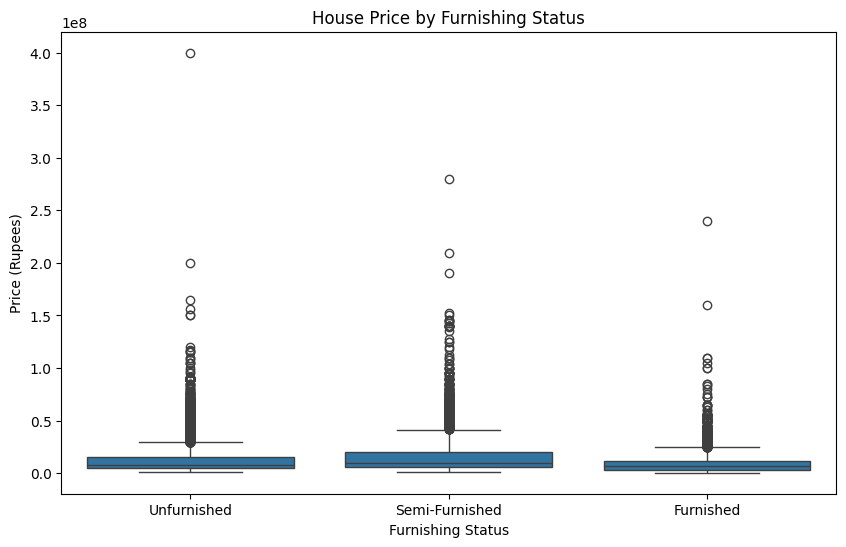

In [198]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Furnishing",
    y="price_clean"
)

plt.title("House Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price (Rupees)")

plt.show()

### 3.5 Price by Number of Bathrooms

More bathrooms typically indicate larger, more premium properties. This box plot confirms the trend.

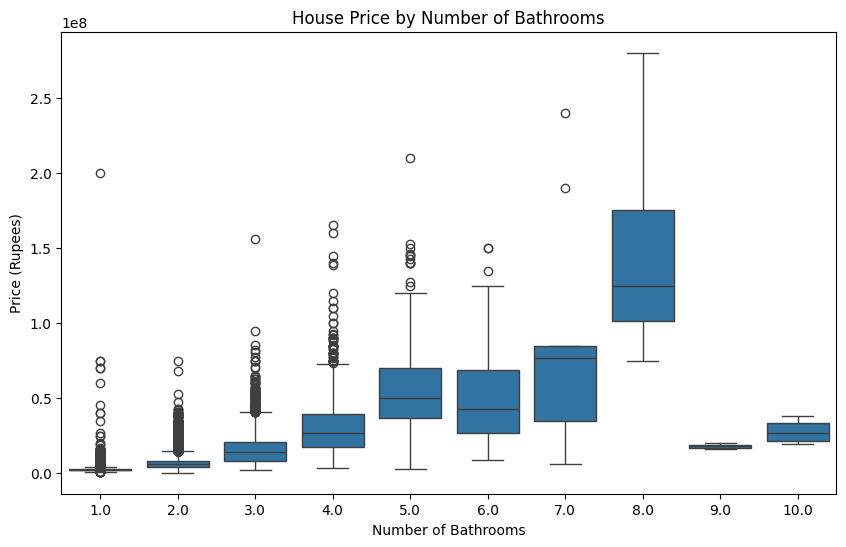

In [199]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Bathroom",
    y="price_clean"
)

plt.title("House Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (Rupees)")

plt.show()

---

## 4. Build a Pipeline & Train

We split the data into **80% train / 20% test**, then build a scikit-learn `Pipeline` that bundles:

1. A `ColumnTransformer` for numeric + categorical preprocessing.
2. Two regression models for comparison.

Bundling preprocessing inside the pipeline ensures the exported model works end-to-end in the backend without any manual encoding.

In [200]:
from sklearn.model_selection import train_test_split

features = [
    "carpet_area_sqft",
    "floor_num",
    "Bathroom",
    "Balcony",
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

target = "price_clean"

X = data[features]
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (95263, 9)
y shape: (95263,)


In [201]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 76210
Testing samples: 19053


In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [203]:
numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "Bathroom",
    "Balcony"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

### 4.1 Preprocessing Pipeline

- **Numeric features** → median imputation + standard scaling.
- **Categorical features** → most-frequent imputation + one-hot encoding (with `handle_unknown="ignore"` to avoid crashes on unseen categories).

In [204]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [205]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

### 4.2 Model 1 — Linear Regression (Baseline)

A simple baseline to compare against more complex models.

In [206]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'Bathroom',
                                                   'Balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('model', LinearRegression())])

In [207]:
y_pred_linear = linear_model.predict(X_test)

### 4.3 Model 2 — Random Forest Regressor

An ensemble of 100 decision trees. Expected to capture non-linear relationships and interactions far better than linear regression.

In [208]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [209]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'Bathroom',
                                                   'Balcony']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [210]:
y_pred_rf = rf_model.predict(X_test)

In [211]:

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_log = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_log.fit(X_train, y_train_log)

y_pred_rf_log = np.expm1(rf_log.predict(X_test))

print("Random Forest (log-transformed target):")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_rf_log):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf_log)):,.2f}")
print(f"R²   : {r2_score(y_test, y_pred_rf_log):.4f}")

Random Forest (log-transformed target):
MAE  : 940,421.69
RMSE : 3,007,236.69
R²   : 0.9489


In [212]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

---

## 5. Evaluate Models

We compare both models on the **test set** using three metrics:

- **MAE** (Mean Absolute Error) — average error in rupees.
- **RMSE** (Root Mean Squared Error) — penalizes large errors more.
- **R²** (Coefficient of Determination) — proportion of variance explained.

In [213]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 30)
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

linear_results = evaluate_model(
    y_test,
    y_pred_linear,
    "Linear Regression"
)

rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)




Linear Regression
------------------------------
MAE  : 4,166,205.72
RMSE : 6,621,137.41
R²   : 0.7523

Random Forest
------------------------------
MAE  : 968,035.37
RMSE : 3,229,036.42
R²   : 0.9411


### 5.1 Model Comparison Table

Summary of all models ranked by R².

In [214]:
results = pd.DataFrame([
    linear_results,
    rf_results
])

results


,Model,MAE,RMSE,R²
0,Linear Regression,4.166206e+06,6.621137e+06,0.752329
1,Random Forest,9.680354e+05,3.229036e+06,0.941095


In [215]:
results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
1,Random Forest,9.680354e+05,3.229036e+06,0.941095
0,Linear Regression,4.166206e+06,6.621137e+06,0.752329


### 5.2 Predicted vs. Actual (Random Forest)

A perfect model would place all points on the dashed diagonal. The tight clustering around the line confirms the model's strong performance across the price range.

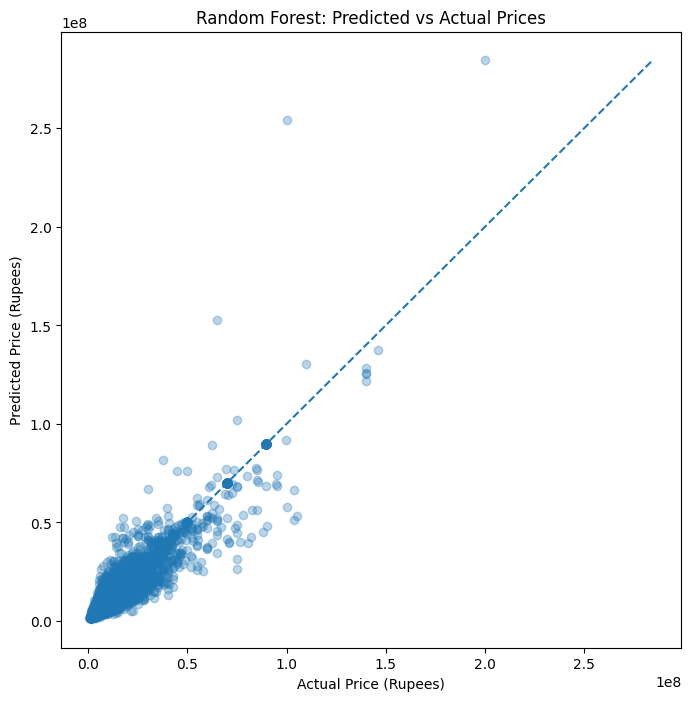

In [216]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Random Forest: Predicted vs Actual Prices")
plt.xlabel("Actual Price (Rupees)")
plt.ylabel("Predicted Price (Rupees)")

plt.show()

---

## 6. Export the Model

Finally, we export:

- `house_price.pkl` — the full pipeline (preprocessing + model).
- `locations.json` — the list of allowed locations for the frontend dropdown.
- The `scikit-learn` version, so the backend can pin the exact same version.

The exported `.pkl` is loaded once at FastAPI startup and used for inference.

In [217]:
# Phase 6 — Export the Model

import joblib
import json
import sklearn

# 1) Save the full pipeline (preprocessing + RandomForest model)
#    Because we exported the FULL Pipeline, the backend won't need
#    any manual encoding — it just loads this file and calls predict().
joblib.dump(rf_model, "house_price.pkl")
print(" Model saved as house_price.pkl")

# 2) Save the list of allowed locations (top-50 + "Other")
#    This is used by the React frontend to populate the dropdown.
locations = sorted(data["location_grouped"].unique().tolist())
json.dump(locations, open("locations.json", "w"), indent=2)
print(f" Saved {len(locations)} locations to locations.json")

# 3) Print sklearn version — MUST be pinned in the backend's requirements.txt
#    A pickle only loads reliably with the same scikit-learn version.
print(f" scikit-learn version: {sklearn.__version__}")
print(f" pandas version      : {pd.__version__}")
print(f" numpy version       : {np.__version__}")

 Model saved as house_price.pkl
 Saved 51 locations to locations.json
 scikit-learn version: 1.6.1
 pandas version      : 2.3.3
 numpy version       : 2.0.2


In [218]:

loaded_model = joblib.load("house_price.pkl")

sample = X_test.iloc[[0]]
original_pred = rf_model.predict(sample)[0]
reloaded_pred = loaded_model.predict(sample)[0]

print("Original model prediction :", f"{original_pred:,.2f} rupees")
print("Reloaded model prediction :", f"{reloaded_pred:,.2f} rupees")
print("Match:", np.isclose(original_pred, reloaded_pred))

# Show the actual price for reference
print("\nActual price for this sample:", f"{y_test.iloc[0]:,.2f} rupees")

Original model prediction : 4,766,000.00 rupees
Reloaded model prediction : 4,766,000.00 rupees
Match: True

Actual price for this sample: 5,500,000.00 rupees


In [219]:

sample_input = pd.DataFrame([{
    "carpet_area_sqft": 1200,
    "floor_num": 5,
    "Bathroom": 2,
    "Balcony": 1,
    "location_grouped": "mumbai",
    "Furnishing": "Semi-Furnished",
    "Transaction": "Resale",
    "Ownership": "Freehold",
    "facing": "East"
}])

predicted_price = loaded_model.predict(sample_input)[0]
print(f" Predicted price: {predicted_price:,.0f} rupees")
print(f" Predicted price: {predicted_price / 1e5:.2f} Lac")
print(f" Predicted price: {predicted_price / 1e7:.2f} Cr")

 Predicted price: 36,974,000 rupees
 Predicted price: 369.74 Lac
 Predicted price: 3.70 Cr


In [220]:
joblib.dump(rf_model, "house_price.pkl", compress=3)

['house_price.pkl']